<a href="https://colab.research.google.com/github/harshithhuk/Dissertation/blob/main/Coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install kagglehub transformers datasets --quiet

In [2]:
# IMPORTS

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Core
import os
import re
import sys
import numpy as np
import pandas as pd

# Force path refresh for newly installed packages
import site
importlib = __import__('importlib')
importlib.reload(site)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Traditional ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Deep Learning
import torch
from torch.utils.data import Dataset

# Transformers
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

print("Transformers version:", transformers.__version__)

Transformers version: 5.0.0


In [3]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Dataset path:", path)

# Load CSV
file_path = os.path.join(path, "training.1600000.processed.noemoticon.csv")

df = pd.read_csv(file_path, encoding='latin-1', header=None)

# Assign column names
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Convert labels: 0 → 0 (negative), 4 → 1 (positive)
df['target'] = df['target'].replace({4: 1})

print(df.shape)
df.head()

Using Colab cache for faster access to the 'sentiment140' dataset.
Dataset path: /kaggle/input/sentiment140
(1600000, 6)


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
# Check missing values
print(df.isnull().sum())

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Drop duplicates (if any)
df = df.drop_duplicates()

# Class balance
print(df['target'].value_counts(normalize=True))

target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64
Duplicate rows: 0
target
0    0.5
1    0.5
Name: proportion, dtype: float64


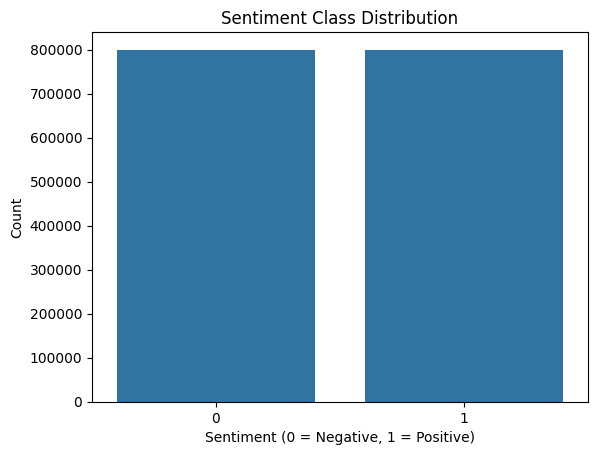

In [5]:
sns.countplot(x='target', data=df)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

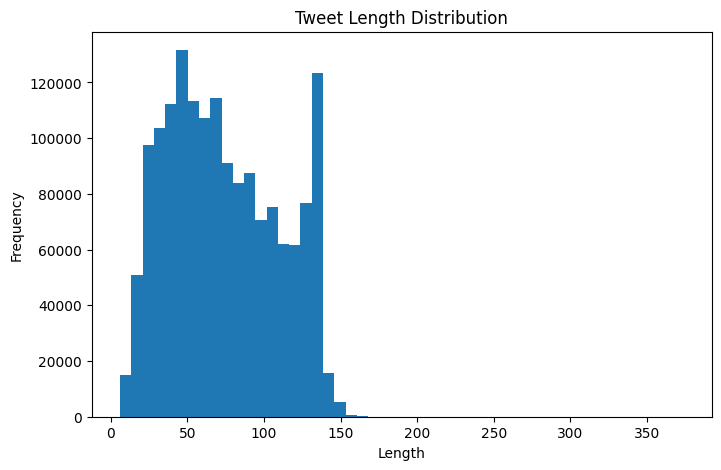

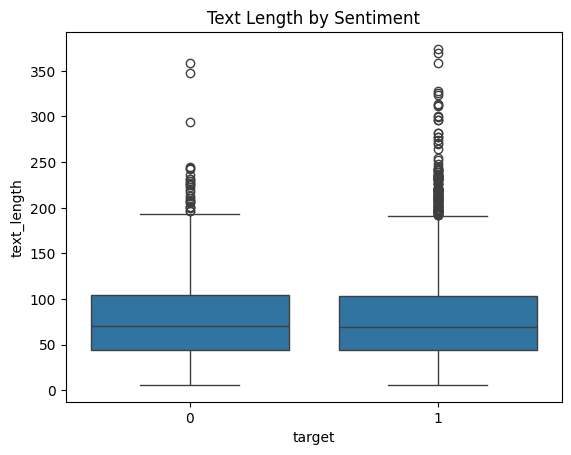

In [6]:
# Length distribution
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(8,5))
plt.hist(df['text_length'], bins=50)
plt.title("Tweet Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# Compare by sentiment
sns.boxplot(x='target', y='text_length', data=df)
plt.title("Text Length by Sentiment")
plt.show()

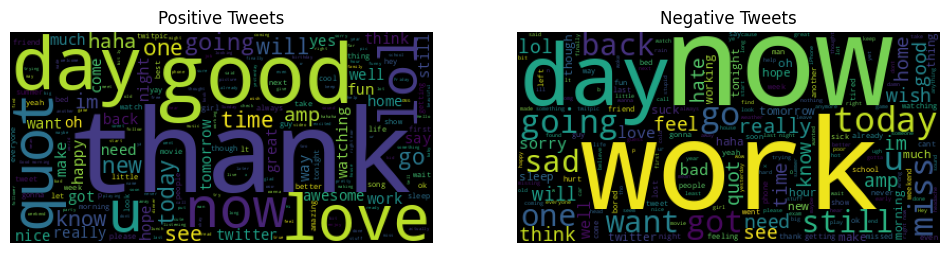

In [7]:
from wordcloud import WordCloud

# Positive tweets
positive_text = " ".join(df[df['target']==1]['text'].sample(5000))

# Negative tweets
negative_text = " ".join(df[df['target']==0]['text'].sample(5000))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(WordCloud().generate(positive_text))
plt.title("Positive Tweets")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(WordCloud().generate(negative_text))
plt.title("Negative Tweets")
plt.axis("off")

plt.show()

In [8]:
import re

# Contraction dictionary (important for sentiment)
contractions = {
    "can't": "can not",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'t": " not",
    "'ve": " have",
    "'m": " am"
}

def expand_contractions(text):
    for key, value in contractions.items():
        text = re.sub(key, value, text)
    return text


def normalize_elongated_words(text):
    """
    Reduce elongated words:
    e.g., 'soooo happyyyy' → 'soo happyy'
    """
    return re.sub(r'(.)\1{2,}', r'\1\1', text)


def handle_negations(text):
    """
    Attach NOT_ to words following negation
    e.g., 'not good' → 'not_good'
    Helps traditional ML capture sentiment flips
    """
    text = re.sub(r'\b(not|no|never)\s+(\w+)', r'\1_\2', text)
    return text


def clean_text_advanced(text):
    """
    Context-aware preprocessing:
    Balances ML needs + Transformer compatibility
    """

    # Lowercase
    text = text.lower()

    # Expand contractions
    text = expand_contractions(text)

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Keep hashtag words but remove '#'
    text = re.sub(r"#", "", text)

    # Normalize elongated words
    text = normalize_elongated_words(text)

    # Handle negations (important for sentiment)
    text = handle_negations(text)

    # Remove excessive punctuation (keep basic structure)
    text = re.sub(r"[^\w\s!?]", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [9]:
df['clean_text'] = df['text'].apply(clean_text_advanced)

df[['text', 'clean_text']].sample(5)

,text,clean_text
462429,hates all cinemas playing &quot;cheesy&quot; m...,hates all cinemas playing quotcheesyquot movie...
637330,"I need to start packing up my stuff, but I don...",i need to start packing up my stuff but i do n...
1435074,@SereneBella had a wonderful performance the p...,had a wonderful performance the past 3 nights
1389244,@Anthonyweeling NIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,niice
789645,"Oh @CazMinx , @steven_mcg - sucks that @MashBu...",oh sucks that lost the battle doh!! are you se...


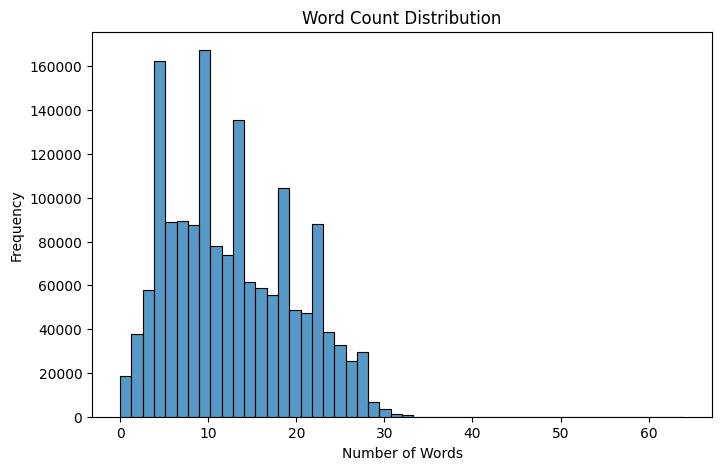

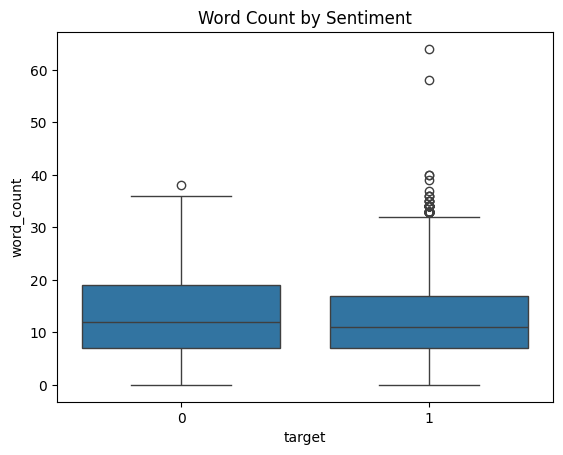

In [10]:
# Word count per tweet
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Compare by sentiment
sns.boxplot(x='target', y='word_count', data=df)
plt.title("Word Count by Sentiment")
plt.show()

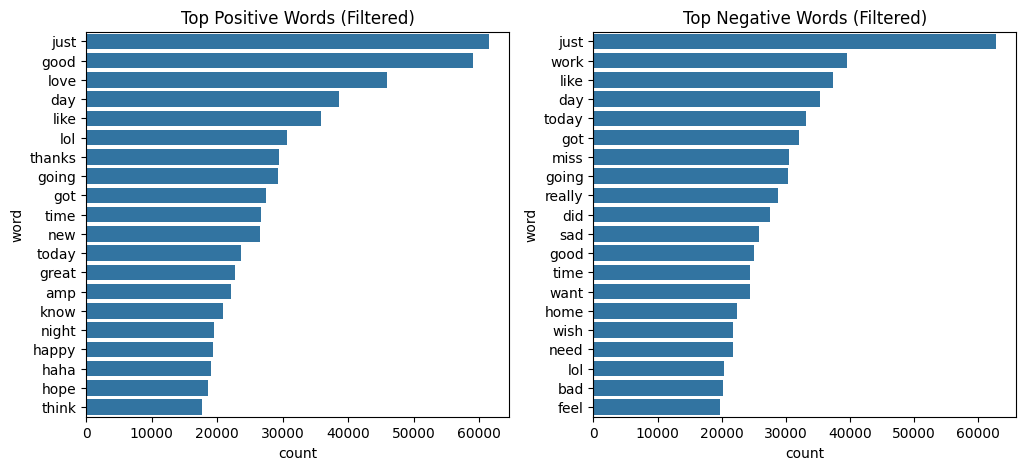

In [11]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)

def get_top_words_filtered(text_series, n=20):
    words = " ".join(text_series).split()

    # Remove stopwords
    filtered_words = [w for w in words if w not in stopwords and len(w) > 2]

    return Counter(filtered_words).most_common(n)

# Positive words
pos_words = get_top_words_filtered(df[df['target']==1]['clean_text'])

# Negative words
neg_words = get_top_words_filtered(df[df['target']==0]['clean_text'])

# Convert to DataFrame
pos_df = pd.DataFrame(pos_words, columns=['word','count'])
neg_df = pd.DataFrame(neg_words, columns=['word','count'])

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.barplot(x='count', y='word', data=pos_df)
plt.title("Top Positive Words (Filtered)")

plt.subplot(1,2,2)
sns.barplot(x='count', y='word', data=neg_df)
plt.title("Top Negative Words (Filtered)")

plt.show()

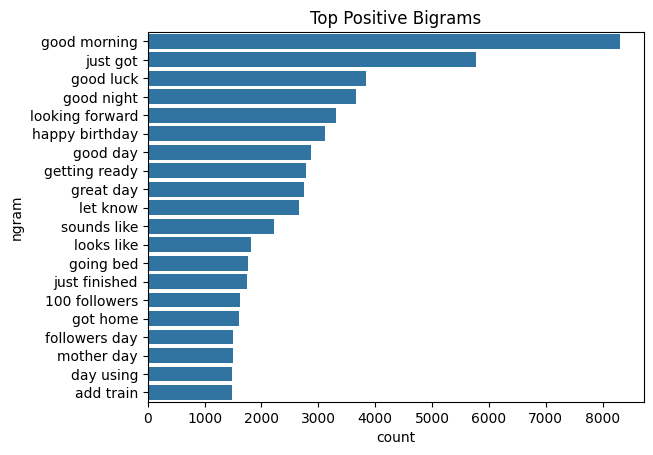

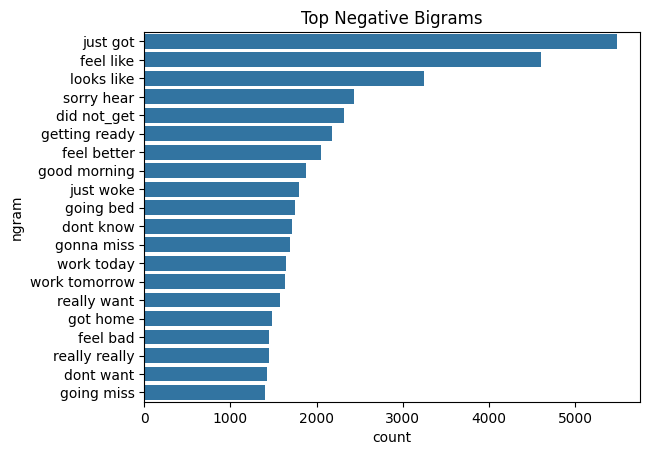

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(corpus, n=20, ngram_range=(2,2), title=""):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    bag = vec.fit_transform(corpus)
    sum_words = bag.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

    df_ngram = pd.DataFrame(words_freq, columns=['ngram','count'])

    sns.barplot(x='count', y='ngram', data=df_ngram)
    plt.title(title)
    plt.show()

# Positive bigrams
plot_top_ngrams(df[df['target']==1]['clean_text'], title="Top Positive Bigrams")

# Negative bigrams
plot_top_ngrams(df[df['target']==0]['clean_text'], title="Top Negative Bigrams")

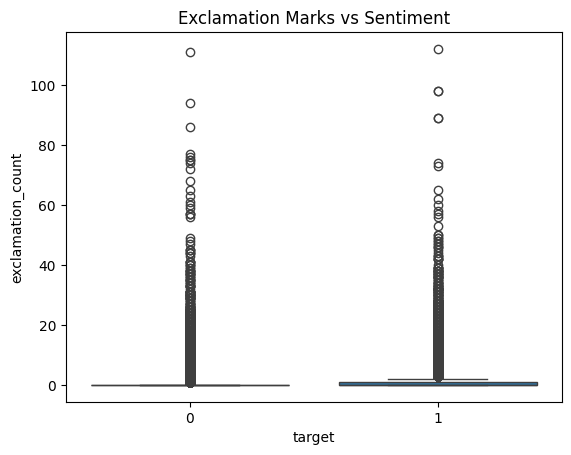

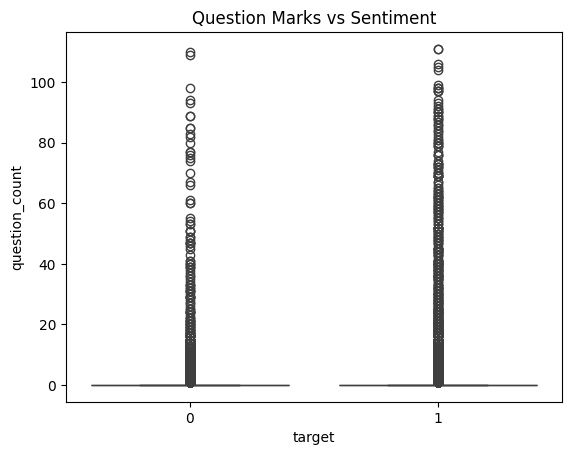

In [13]:
# Count emojis / special characters
df['exclamation_count'] = df['text'].apply(lambda x: x.count('!'))
df['question_count'] = df['text'].apply(lambda x: x.count('?'))

# Compare distributions
sns.boxplot(x='target', y='exclamation_count', data=df)
plt.title("Exclamation Marks vs Sentiment")
plt.show()

sns.boxplot(x='target', y='question_count', data=df)
plt.title("Question Marks vs Sentiment")
plt.show()

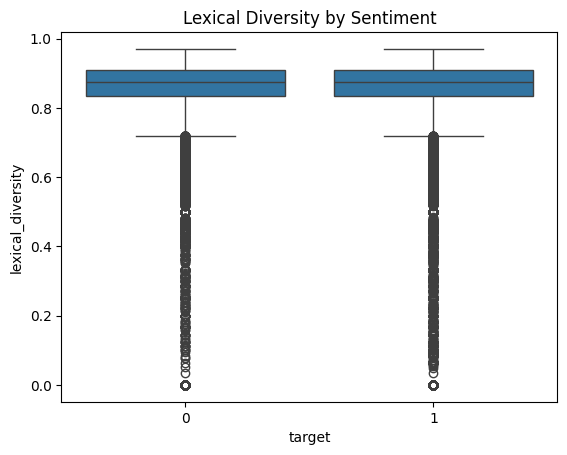

In [14]:
def lexical_diversity(text):
    words = text.split()
    return len(set(words)) / (len(words) + 1)

df['lexical_diversity'] = df['clean_text'].apply(lexical_diversity)

sns.boxplot(x='target', y='lexical_diversity', data=df)
plt.title("Lexical Diversity by Sentiment")
plt.show()

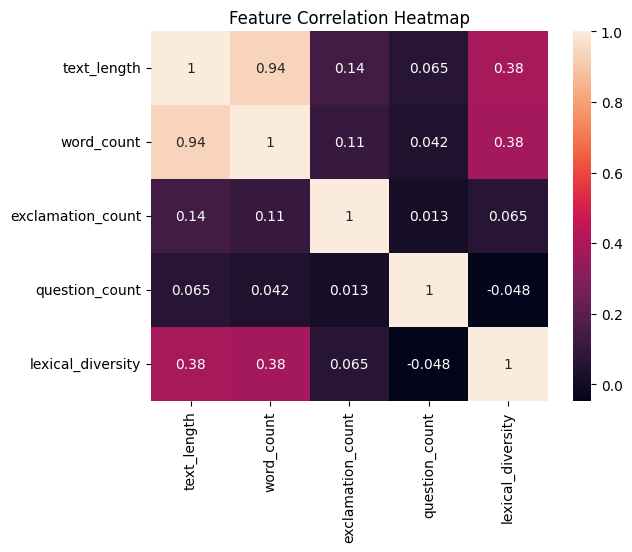

In [15]:
features = ['text_length', 'word_count', 'exclamation_count', 'question_count', 'lexical_diversity']

sns.heatmap(df[features].corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

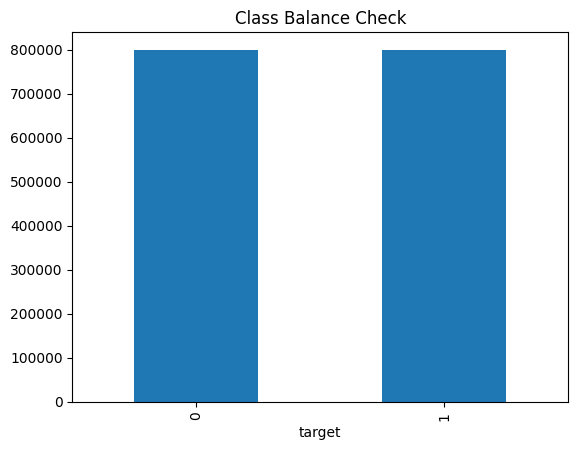

In [16]:
df['target'].value_counts().plot(kind='bar')
plt.title("Class Balance Check")
plt.show()

In [17]:
# Use subset for faster training
df_sample = df.sample(50000, random_state=42)

X = df_sample['clean_text']
y = df_sample['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 40000
Test size: 10000


In [18]:
# TF-IDF VECTORIZATION

from sklearn.feature_extraction.text import TfidfVectorizer

# Configure vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8,
    sublinear_tf=True,
    stop_words='english'
)

# Fit on training data ONLY (avoids data leakage)
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

TF-IDF shape (train): (40000, 5000)
TF-IDF shape (test): (10000, 5000)


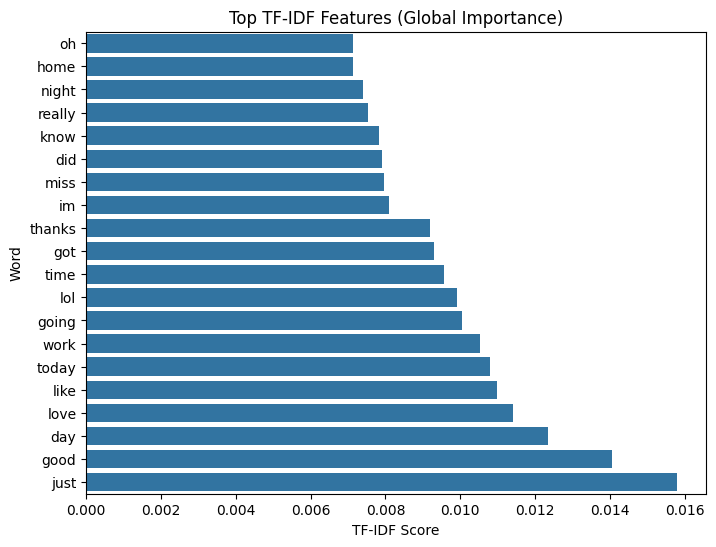

In [19]:
# GLOBAL TF-IDF FEATURE IMPORTANCE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names
feature_names = np.array(tfidf.get_feature_names_out())

# Compute mean TF-IDF score across training data
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()

# Top features
top_indices = np.argsort(mean_tfidf)[-20:]
top_features = feature_names[top_indices]
top_scores = mean_tfidf[top_indices]

# Create DataFrame
tfidf_df = pd.DataFrame({
    'word': top_features,
    'score': top_scores
}).sort_values(by='score')

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x='score', y='word', data=tfidf_df)
plt.title("Top TF-IDF Features (Global Importance)")
plt.xlabel("TF-IDF Score")
plt.ylabel("Word")
plt.show()

In [20]:
# CLASS-WISE TF-IDF DIFFERENCE

feature_names = np.array(tfidf.get_feature_names_out())

# Convert labels to NumPy
y_train_np = y_train.values

# Proper indexing
X_pos = X_train_tfidf[y_train_np == 1]
X_neg = X_train_tfidf[y_train_np == 0]

# Mean TF-IDF per class
pos_mean = np.asarray(X_pos.mean(axis=0)).flatten()
neg_mean = np.asarray(X_neg.mean(axis=0)).flatten()

# Difference
diff = pos_mean - neg_mean

# Top features
top_pos_idx = np.argsort(diff)[-20:]
top_neg_idx = np.argsort(diff)[:20]

# DataFrames
pos_df = pd.DataFrame({
    'word': feature_names[top_pos_idx],
    'score': diff[top_pos_idx]
}).sort_values(by='score')

neg_df = pd.DataFrame({
    'word': feature_names[top_neg_idx],
    'score': diff[top_neg_idx]
}).sort_values(by='score')

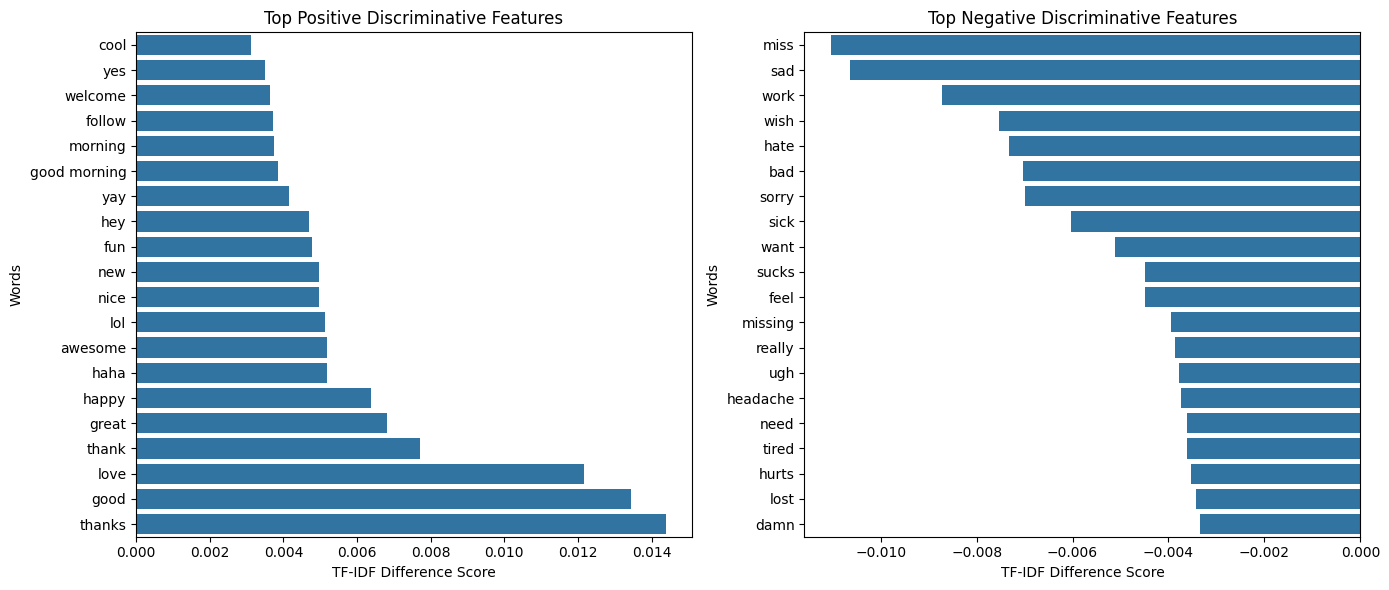

In [21]:
# VISUALIZATION: DISCRIMINATIVE FEATURES

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

# Positive features
plt.subplot(1,2,1)
sns.barplot(
    x='score',
    y='word',
    data=pos_df.sort_values(by='score', ascending=True)
)
plt.title("Top Positive Discriminative Features")
plt.xlabel("TF-IDF Difference Score")
plt.ylabel("Words")

# Negative features
plt.subplot(1,2,2)
sns.barplot(
    x='score',
    y='word',
    data=neg_df.sort_values(by='score', ascending=True)
)
plt.title("Top Negative Discriminative Features")
plt.xlabel("TF-IDF Difference Score")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

Sparsity of TF-IDF matrix: 0.001059


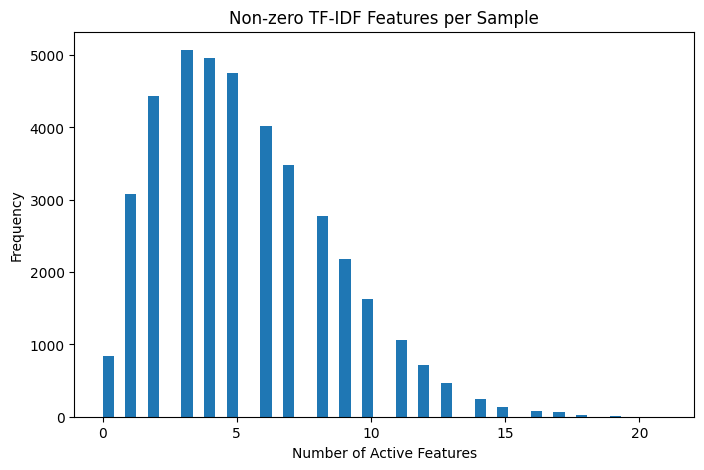

In [22]:
# SPARSITY ANALYSIS

# Percentage of non-zero elements
sparsity = (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))

print(f"Sparsity of TF-IDF matrix: {sparsity:.6f}")

# Visualize distribution of non-zero values per sample
nonzero_counts = (X_train_tfidf != 0).sum(axis=1)

plt.figure(figsize=(8,5))
plt.hist(nonzero_counts, bins=50)
plt.title("Non-zero TF-IDF Features per Sample")
plt.xlabel("Number of Active Features")
plt.ylabel("Frequency")
plt.show()

In [23]:
# MODEL TRAINING FUNCTION

def train_model(model, X_train, y_train):
    """
    Trains a given model and returns the trained model
    """
    model.fit(X_train, y_train)
    return model

In [24]:
# EVALUATION FUNCTION

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluates model performance and plots confusion matrix
    """
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, prec, rec, f1


===== Logistic Regression =====
Accuracy : 0.7552
Precision: 0.7477
Recall   : 0.7736
F1 Score : 0.7605

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.74      0.75      4977
           1       0.75      0.77      0.76      5023

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



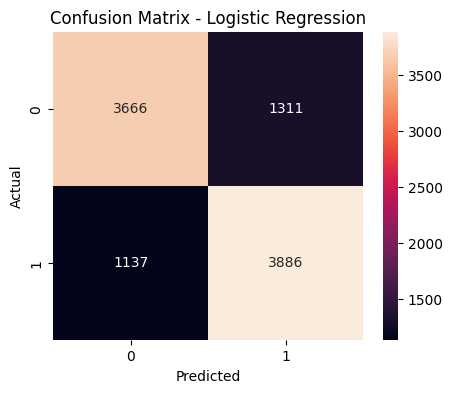

In [25]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=300,
    n_jobs=-1,
    class_weight='balanced'
)

lr_model = train_model(lr_model, X_train_tfidf, y_train)

lr_results = evaluate_model(lr_model, X_test_tfidf, y_test, "Logistic Regression")


===== Random Forest =====
Accuracy : 0.7195
Precision: 0.6818
Recall   : 0.8280
F1 Score : 0.7478

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.61      0.68      4977
           1       0.68      0.83      0.75      5023

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



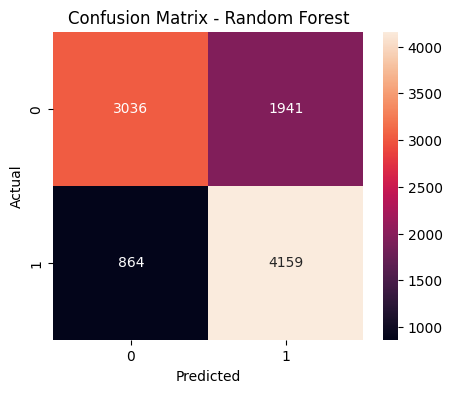

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_model = train_model(rf_model, X_train_tfidf, y_train)

rf_results = evaluate_model(rf_model, X_test_tfidf, y_test, "Random Forest")

In [27]:
# COMPARISON TABLE

results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_results[0], rf_results[0]],
    'Precision': [lr_results[1], rf_results[1]],
    'Recall': [lr_results[2], rf_results[2]],
    'F1 Score': [lr_results[3], rf_results[3]]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7552,0.747739,0.773641,0.76047
1,Random Forest,0.7195,0.681803,0.827991,0.74782


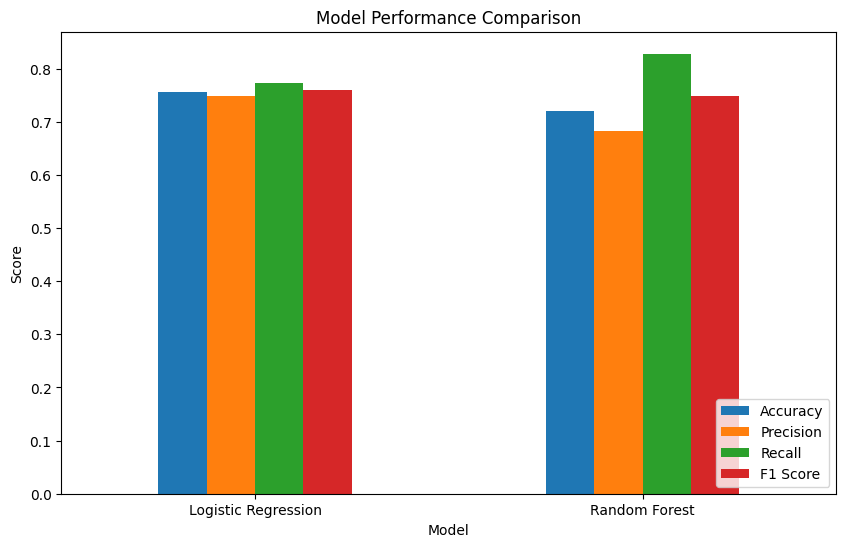

In [28]:
# BAR PLOT COMPARISON

results_df.set_index('Model').plot(kind='bar', figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [29]:
# CUSTOM DATASET CLASS

from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [30]:
# !pip install transformers==4.38.0

In [31]:
# TRAINING CONFIGURATION

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="steps",
    eval_steps=200,
    logging_strategy="steps",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    fp16=True
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Accuracy
200,0.440890,0.466700,0.768400
400,0.412608,0.412038,0.816000
600,0.431127,0.431013,0.807300
800,0.434779,0.395535,0.820300
1000,0.387274,0.423348,0.818100
1200,0.395527,0.388888,0.827500
1400,0.286994,0.430480,0.824500
1600,0.228314,0.442469,0.824800
1800,0.228173,0.431689,0.825400
2000,0.263689,0.447423,0.823200



BERT Results:
Accuracy : 0.8322
Precision: 0.8462
Recall   : 0.8139
F1 Score : 0.8297


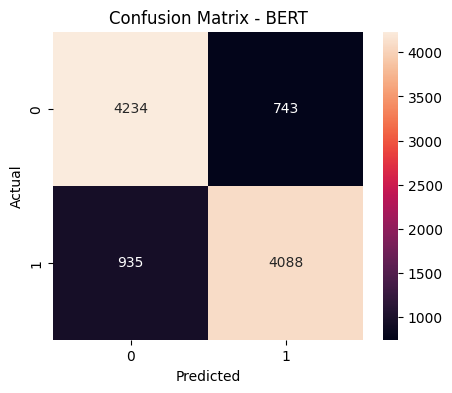

In [32]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# TOKENIZER + MODEL

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# DATASETS

train_dataset = SentimentDataset(X_train, y_train, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)

# METRICS FUNCTION

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

# TRAINER

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# TRAIN

trainer.train()

# PREDICTIONS

y_test_np = np.array(y_test)

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

# METRICS

acc = accuracy_score(y_test_np, y_pred)
prec = precision_score(y_test_np, y_pred, zero_division=0)
rec = recall_score(y_test_np, y_pred, zero_division=0)
f1 = f1_score(y_test_np, y_pred, zero_division=0)

print("\nBERT Results:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# CONFUSION MATRIX

cm = confusion_matrix(y_test_np, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - BERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

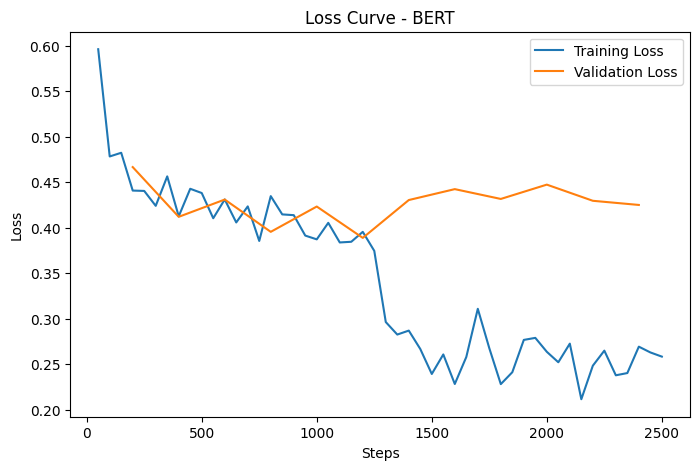

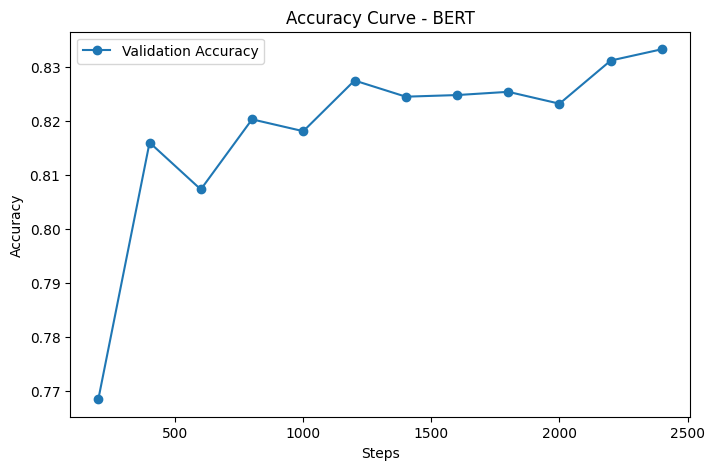

In [33]:
logs = trainer.state.log_history

train_loss, eval_loss = [], []
steps_train, steps_eval = [], []

eval_acc, steps_acc = [], []

for log in logs:
    if 'loss' in log:
        train_loss.append(log['loss'])
        steps_train.append(log['step'])

    if 'eval_loss' in log:
        eval_loss.append(log['eval_loss'])
        steps_eval.append(log['step'])

    if 'eval_accuracy' in log:
        eval_acc.append(log['eval_accuracy'])
        steps_acc.append(log['step'])

# LOSS CURVE

plt.figure(figsize=(8,5))
plt.plot(steps_train, train_loss, label='Training Loss')

if len(eval_loss) > 0:
    plt.plot(steps_eval, eval_loss, label='Validation Loss')

plt.title("Loss Curve - BERT")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ACCURACY CURVE

if len(eval_acc) > 0:
    plt.figure(figsize=(8,5))
    plt.plot(steps_acc, eval_acc, marker='o', label='Validation Accuracy')
    plt.title("Accuracy Curve - BERT")
    plt.xlabel("Steps")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Accuracy
200,0.443527,0.443321,0.805700
400,0.427851,0.414551,0.823900
600,0.434787,0.447239,0.783000
800,0.441203,0.383581,0.830800
1000,0.395819,0.417501,0.830200
1200,0.394133,0.399619,0.831000
1400,0.335433,0.392625,0.842200
1600,0.275295,0.423088,0.839700
1800,0.286472,0.384941,0.836100
2000,0.314237,0.394600,0.840200



RoBERTa Results:
Accuracy : 0.8425
Precision: 0.8614255765199161
Recall   : 0.8180370296635476
F1 Score : 0.8391708363116511


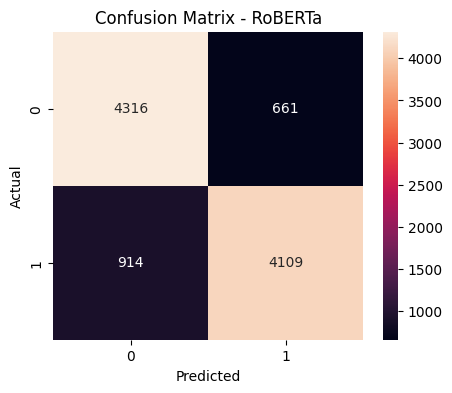

In [34]:
# RoBERTa MODEL

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load tokenizer & model
roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

# Reuse datasets
train_dataset = SentimentDataset(X_train, y_train, roberta_tokenizer)
test_dataset = SentimentDataset(X_test, y_test, roberta_tokenizer)

# Rename trainer for uniqueness
roberta_trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train
roberta_trainer.train()

# EVALUATION

y_test_np = np.array(y_test)
predictions = roberta_trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nRoBERTa Results:")
print("Accuracy :", accuracy_score(y_test_np, y_pred))
print("Precision:", precision_score(y_test_np, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test_np, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test_np, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - RoBERTa")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

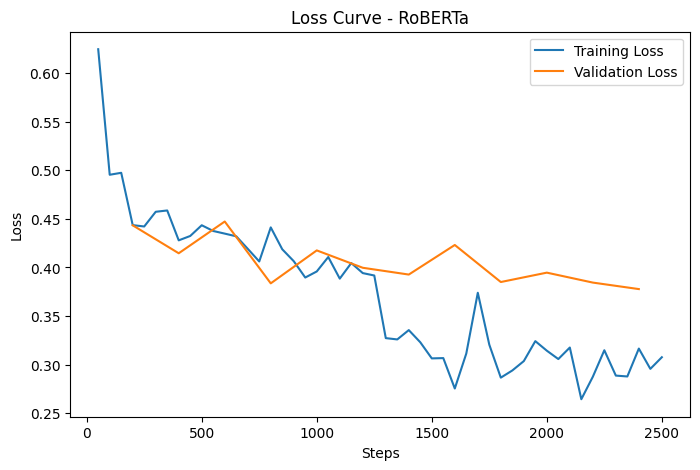

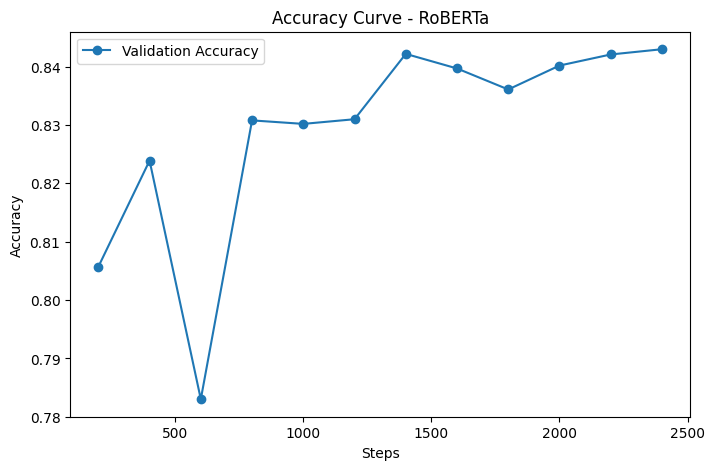

In [35]:
# RoBERTa TRAINING CURVES

logs = roberta_trainer.state.log_history

train_loss, eval_loss = [], []
steps_train, steps_eval = [], []
eval_acc, steps_acc = [], []

for log in logs:
    if 'loss' in log:
        train_loss.append(log['loss'])
        steps_train.append(log['step'])

    if 'eval_loss' in log:
        eval_loss.append(log['eval_loss'])
        steps_eval.append(log['step'])

    if 'eval_accuracy' in log:
        eval_acc.append(log['eval_accuracy'])
        steps_acc.append(log['step'])

plt.figure(figsize=(8,5))
plt.plot(steps_train, train_loss, label='Training Loss')

if eval_loss:
    plt.plot(steps_eval, eval_loss, label='Validation Loss')

plt.title("Loss Curve - RoBERTa")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.show()

if eval_acc:
    plt.figure(figsize=(8,5))
    plt.plot(steps_acc, eval_acc, marker='o', label='Validation Accuracy')
    plt.title("Accuracy Curve - RoBERTa")
    plt.xlabel("Steps")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Step,Training Loss,Validation Loss,Accuracy
200,0.480139,0.446019,0.794600
400,0.451910,0.443092,0.800400
600,0.476611,0.436475,0.807600
800,0.452493,0.420454,0.818300
1000,0.445624,0.415338,0.819600
1200,0.425321,0.407052,0.820900
1400,0.354294,0.432971,0.826300
1600,0.321504,0.418292,0.826400
1800,0.319377,0.425819,0.823800
2000,0.333251,0.425346,0.823700



XLNet Results:
Accuracy : 0.8295
Precision: 0.8424855491329479
Recall   : 0.8124626717101334
F1 Score : 0.8272017837235228


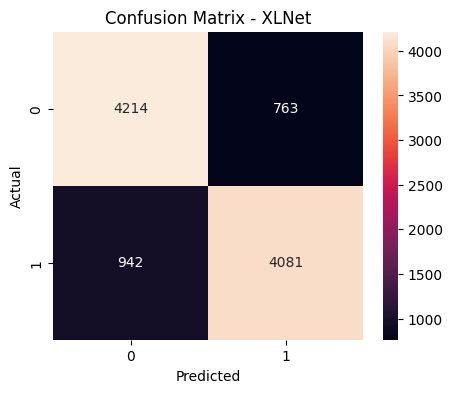

In [36]:
# XLNet MODEL

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load tokenizer & model
xlnet_tokenizer = AutoTokenizer.from_pretrained("xlnet-base-cased")

xlnet_model = AutoModelForSequenceClassification.from_pretrained(
    "xlnet-base-cased",
    num_labels=2
)

# Reuse datasets
train_dataset = SentimentDataset(X_train, y_train, xlnet_tokenizer)
test_dataset = SentimentDataset(X_test, y_test, xlnet_tokenizer)

# METRICS FUNCTION

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

# Trainer (unique name)
xlnet_trainer = Trainer(
    model=xlnet_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train
xlnet_trainer.train()

# EVALUATION

y_test_np = np.array(y_test)
predictions = xlnet_trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nXLNet Results:")
print("Accuracy :", accuracy_score(y_test_np, y_pred))
print("Precision:", precision_score(y_test_np, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test_np, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test_np, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - XLNet")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

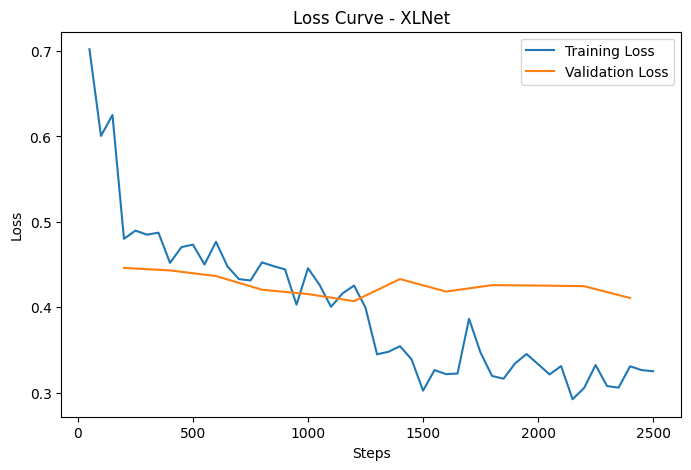

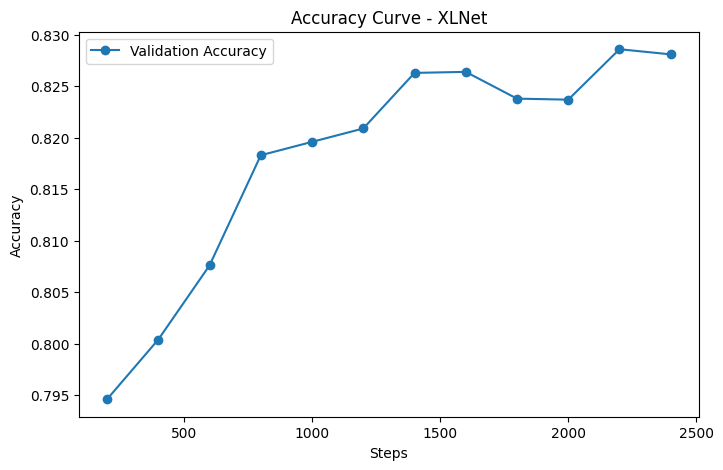

In [37]:
# XLNet TRAINING CURVES

logs = xlnet_trainer.state.log_history

train_loss, eval_loss = [], []
steps_train, steps_eval = [], []
eval_acc, steps_acc = [], []

for log in logs:
    if 'loss' in log:
        train_loss.append(log['loss'])
        steps_train.append(log['step'])

    if 'eval_loss' in log:
        eval_loss.append(log['eval_loss'])
        steps_eval.append(log['step'])

    if 'eval_accuracy' in log:
        eval_acc.append(log['eval_accuracy'])
        steps_acc.append(log['step'])

# ===== LOSS CURVE =====
plt.figure(figsize=(8,5))
plt.plot(steps_train, train_loss, label='Training Loss')

if eval_loss:
    plt.plot(steps_eval, eval_loss, label='Validation Loss')

plt.title("Loss Curve - XLNet")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ===== ACCURACY CURVE =====
if eval_acc:
    plt.figure(figsize=(8,5))
    plt.plot(steps_acc, eval_acc, marker='o', label='Validation Accuracy')
    plt.title("Accuracy Curve - XLNet")
    plt.xlabel("Steps")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [38]:
import torch
import torch.nn.functional as F

def predict_sentiment_pro(text, model, tokenizer):
    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits

        # Convert to probabilities
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

        pred_class = int(np.argmax(probs))
        confidence = float(np.max(probs))

    label = "Positive" if pred_class == 1 else "Negative"

    return {
        "text": text,
        "prediction": label,
        "confidence": round(confidence, 4),
        "probabilities": {
            "Negative": round(float(probs[0]), 4),
            "Positive": round(float(probs[1]), 4)
        }
    }

In [39]:
samples = [
    "I absolutely love this product, it is amazing!",
    "This is the worst experience I have ever had.",
    "The service was okay, nothing special.",
    "I am very happy with the results!",
    "I hate how bad this turned out."
]

for s in samples:
    result = predict_sentiment_pro(s, roberta_model, roberta_tokenizer)
    print(result)
    print("-" * 60)

{'text': 'I absolutely love this product, it is amazing!', 'prediction': 'Positive', 'confidence': 0.9937, 'probabilities': {'Negative': 0.0063, 'Positive': 0.9937}}
------------------------------------------------------------
{'text': 'This is the worst experience I have ever had.', 'prediction': 'Negative', 'confidence': 0.9856, 'probabilities': {'Negative': 0.9856, 'Positive': 0.0144}}
------------------------------------------------------------
{'text': 'The service was okay, nothing special.', 'prediction': 'Positive', 'confidence': 0.725, 'probabilities': {'Negative': 0.275, 'Positive': 0.725}}
------------------------------------------------------------
{'text': 'I am very happy with the results!', 'prediction': 'Positive', 'confidence': 0.9938, 'probabilities': {'Negative': 0.0062, 'Positive': 0.9938}}
------------------------------------------------------------
{'text': 'I hate how bad this turned out.', 'prediction': 'Negative', 'confidence': 0.9842, 'probabilities': {'Negati